In [1]:
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from utils import *
from src.drd import AutoEncoder
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-06 11:35:04.518125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762446904.531063  116373 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762446904.535121  116373 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762446904.545430  116373 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [2]:
PATH_PREFIX = "/shared/share_mala/irchang/drd"
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, activation=torch.nn.SELU):
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=activation,            # match training!
        bottleneck_activation=None
    )

    sd = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

In [4]:
mnist_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(1):
    for c in np.unique(np.logspace(np.log10(2), np.log10(100), 15).astype(int)):
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/vanillaAE_{c}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000,1000,1000,1000,1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "vanilla AE"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/umap{c}_18_0.1_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000,1000,1000,1000,1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + UMAP"})

        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        train_recon = ((X - X_hat)**2).mean()
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/pca{c}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000,1000,1000,1000,1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/spectral{c}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000,1000,1000,1000,1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + Spectral"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/linearAE_pca{c}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000,1000,1000,1000,1000],
                latent_dim=c, activation=None)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained Linear AE + PCA"})

encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=1000, bias=True)
  (9): SELU()
  (10): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=784, bias=True)]
loaded params: 24 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=784, out_features=1000, bias=True)
  (1): S

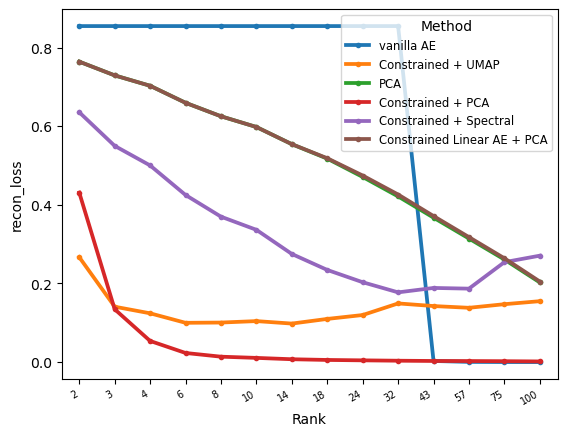

In [5]:
analysis = pd.DataFrame(mnist_res_dict)
sns.pointplot(data=analysis, x='n_components', y='recon_loss', hue='method', errorbar=None, markersize=2, )

plt.xticks(rotation=30, fontsize=7, ha='right')
plt.xlabel("Rank")
plt.legend(title="Method", fontsize='small')
plt.show()

In [8]:
from pathlib import Path
import os, tarfile, hashlib, torch

def audit_ckpt(path):
    p = Path(path)
    print(f"[path] {p}")
    if not p.exists():
        print("❌ missing file")
        return

    sz = p.stat().st_size
    print(f"[size] {sz} bytes")
    if sz < 1024:  # tiny file almost surely broken
        print("⚠️ suspiciously small — likely truncated/corrupted")
    
    # try to see if it's a tar (legacy) archive
    is_tar = False
    try:
        with tarfile.open(p, mode="r:") as tf:
            is_tar = True
            names = [m.name for m in tf.getmembers()]
            print(f"[tar] members (first 10): {names[:10]}")
            print(f"[tar] has 'storages'? {'storages' in names}")
    except tarfile.ReadError:
        print("[tar] not a legacy tar archive (could be modern pickle/zip)")

    # try both load paths
    for wonly in (True, False):
        try:
            obj = torch.load(p, map_location="cpu", weights_only=wonly)
            # light check: obj should be dict-like
            ok = isinstance(obj, dict)
            print(f"[torch.load weights_only={wonly}] ✅ loaded; dict-like={ok}")
            break
        except Exception as e:
            print(f"[torch.load weights_only={wonly}] ❌ {type(e).__name__}: {e}")
    
    # stable hash (useful to see if multiple runs produce *identically* broken files)
    h = hashlib.md5(p.read_bytes()).hexdigest()
    print(f"[md5] {h}")

# example:
audit_ckpt(Path(PATH_PREFIX) / "tmp_results/chkpt/mnist/spectral2_0_ckpts/final.pt")


[path] /shared/share_mala/irchang/drd/tmp_results/chkpt/mnist/spectral2_0_ckpts/final.pt
❌ missing file


In [12]:
gene_cancer_res_dict = []
X, X_test, y, y_test = load_and_split("gene_cancer", test_size=0.2, seed=0, labels=True)
for s in range(1):
    for c in np.unique(np.logspace(np.log10(2), np.log10(100), 15).astype(int)):
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/vanillaAE_{c}_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "vanilla AE"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/umap{c}_9_0.1_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + UMAP"})

        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        train_recon = ((X - X_hat)**2).mean()
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/pca{c}_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/spectral{c}_11_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000,1000,1000,1000],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + Spectral"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/linearAE_pca{c}_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000,1000,1000,1000],
                latent_dim=c, activation=None)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained Linear AE + PCA"})


encoder layers: Sequential(
  (0): Linear(in_features=20531, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=1000, bias=True), SELU(), Linear(in_features=1000, out_features=20531, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=20531, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bi

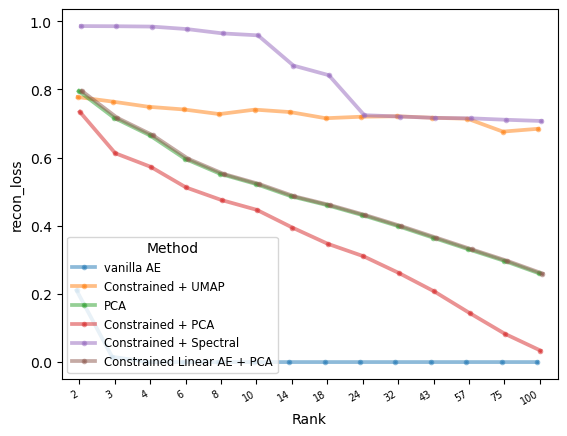

In [13]:
analysis = pd.DataFrame(gene_cancer_res_dict)
sns.pointplot(data=analysis, x='n_components', y='recon_loss', hue='method', errorbar=None, markersize=2, alpha=0.5, dodge=True)

plt.xticks(rotation=30, fontsize=7, ha='right')
plt.xlabel("Rank")
plt.legend(title="Method", fontsize='small')
plt.show()

## Wine data
<!-- Red arrow = No activation, Green arrow = SELU activation

![](/user/bnc2119/drd/wine_architecture.png) -->

In [ ]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/wine.csv')
df = analysis[columnss]
df = df.sort_values(by='recon_loss')
pd.set_option('display.float_format', '{:.6e}'.format)
(df
  .style
  .background_gradient(subset=["distill_loss","recon_loss","time_total_s"],
                       cmap="viridis")
  .format({"distill_loss":"{:.6e}"})
  .set_caption("Hyperparameter Results"))

,distill_loss,recon_loss,time_total_s,config/teacher_config/teacher,config/teacher_config/t_n_neighbors,config/teacher_config/min_dist,config/teacher_config/perplexity,config/teacher_config/learning_rate
7,2.261013e-10,0.099482,1970.469585,tsne,nan,nan,30.000000,300.000000
9,1.173212e-09,0.101209,1895.327933,tsne,nan,nan,50.000000,300.000000
6,2.158119e-10,0.109476,1891.452716,tsne,nan,nan,30.000000,200.000000
8,6.889334e-10,0.109478,1972.391455,tsne,nan,nan,50.000000,200.000000
2,9.253214e-09,0.136924,3780.565160,umap,15.000000,0.010000,nan,nan
1,5.260019e-09,0.138552,3778.257993,umap,10.000000,0.100000,nan,nan
0,1.075634e-08,0.139695,3773.828948,umap,10.000000,0.010000,nan,nan
4,6.128851e-09,0.140989,3781.976525,umap,20.000000,0.010000,nan,nan
3,4.609693e-09,0.144554,3781.753117,umap,15.000000,0.100000,nan,nan
5,4.939715e-09,0.151676,3780.990306,umap,20.000000,0.100000,nan,nan


## MNIST data

<!-- Red arrow = No activation, Green arrow = SELU activation

![](/user/bnc2119/drd/mnist_architecture.png) -->

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_mnist_from_scratch.csv')
# analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist_from_scratch2.csv')
# analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.distill_loss < 0.1]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_mnist_from_pretrained.csv')
# analysis_from_pretrained2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist_from_pretrained2.csv')
# analysis_from_pretrained = pd.concat([analysis_from_pretrained, analysis_from_pretrained2], ignore_index=True)
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

/tmp/ipykernel_110985/3406543892.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_110985/3406543892.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'


/tmp/ipykernel_110985/3138892948.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_110985/3138892948.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


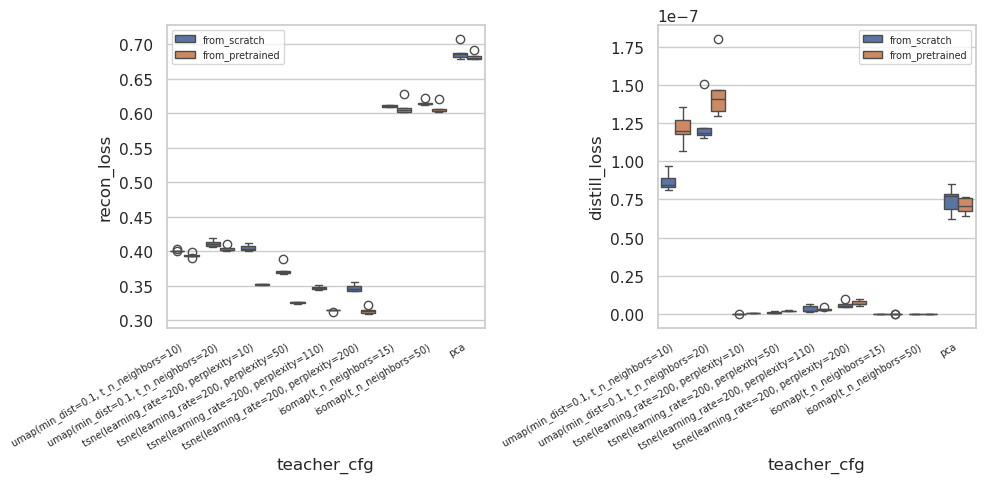

In [ ]:
present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_114026/3873201064.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_114026/3873201064.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'
/tmp/ipykernel_114026/3873201064.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right'

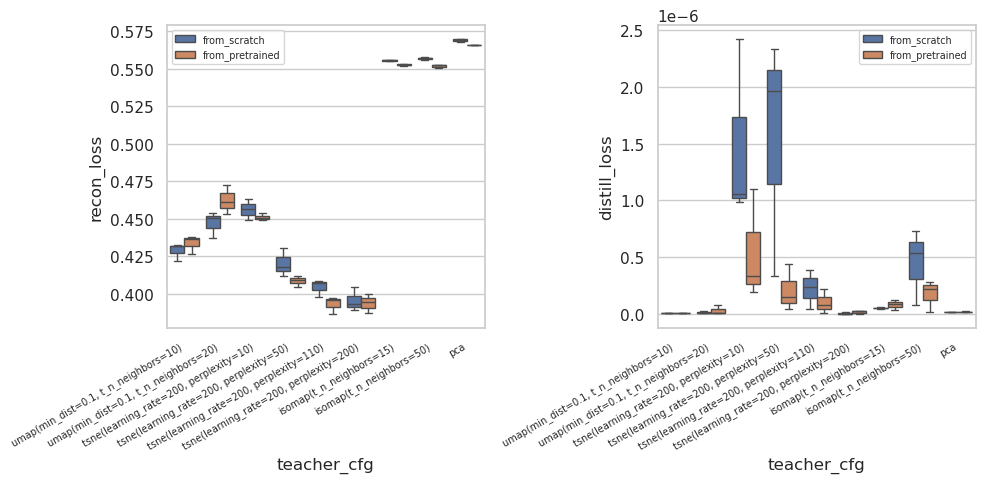

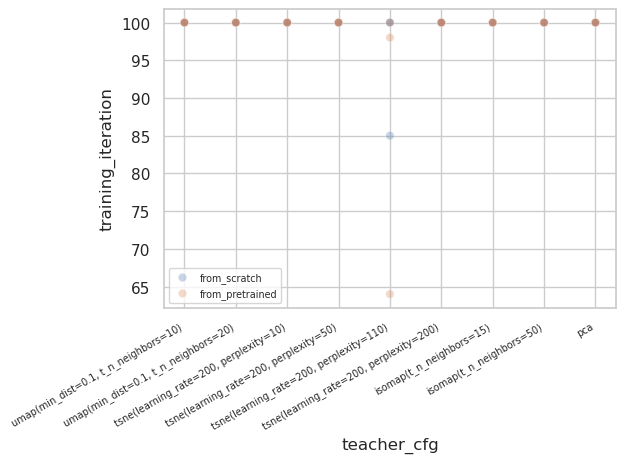

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist1k_from_scratch.csv')
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist1k_from_pretrained.csv')
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

sns.scatterplot(data=analysis_both, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting', alpha=0.3)
plt.xticks(rotation=30, fontsize=7, ha='right')
plt.legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

## Single Cell data

<!-- ![](/user/bnc2119/drd/single_cell_architecture.png) -->

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_scratch.csv')
analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_scratch2.csv')
analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_pretrained.csv')
analysis_from_pretrained2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_pretrained2.csv')
analysis_from_pretrained = pd.concat([analysis_from_pretrained, analysis_from_pretrained2], ignore_index=True)
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

/tmp/ipykernel_118885/1430140271.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_118885/1430140271.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'


/tmp/ipykernel_118885/2818806538.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_118885/2818806538.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


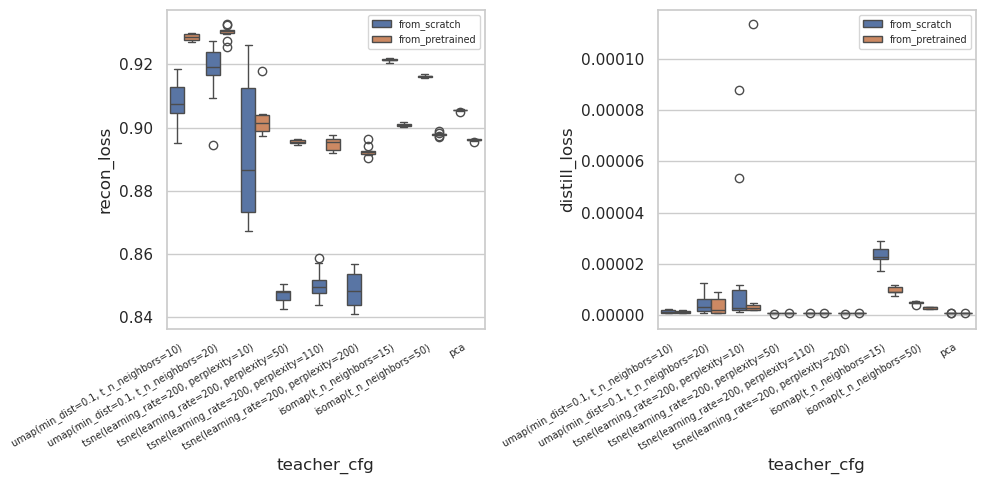

In [ ]:
present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both_sc = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_118885/403697329.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_118885/403697329.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


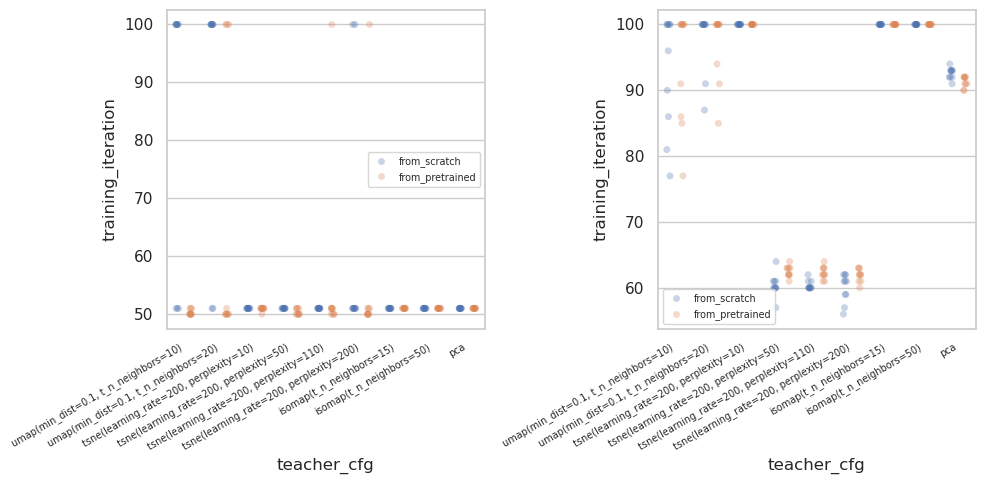

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.stripplot(data=analysis_both_pc, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting', alpha=0.3, ax = axes[0], dodge=True)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.stripplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting',alpha=0.3, ax = axes[1], dodge=True)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_110985/3152137547.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_110985/3152137547.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'
/tmp/ipykernel_110985/3152137547.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

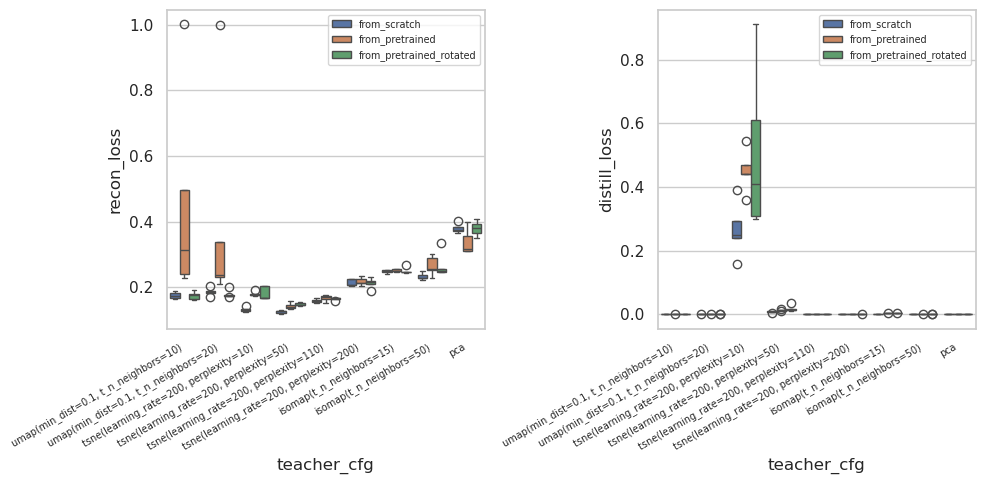

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_scratch.csv')
# analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_scratch2.csv')
# analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)

param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_pretrained.csv')
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.distill_loss < 0.01]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

analysis_from_pretrained_rot = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_diabetes_from_pretrained.csv')
analysis_from_pretrained_rot = analysis_from_pretrained_rot[analysis_from_pretrained_rot.distill_loss < 1]
param_cols = [c for c in analysis_from_pretrained_rot.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained_rot['teacher_cfg'] = analysis_from_pretrained_rot.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained_rot = analysis_from_pretrained_rot[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
df_pretrained_rot['setting'] = 'from_pretrained_rotated'
analysis = pd.concat([df_scratch, df_pretrained, df_pretrained_rot], ignore_index=True)

present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0) & (present['from_pretrained_rotated'] > 0), 'teacher_cfg']
analysis_both_sc = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()

plt.show()